In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.feature_selection import RFECV, RFE
import statsmodels.api as sm
import statsmodels.formula.api as smf

Load Data

In [4]:
univData = pd.read_csv("../Data/Clean/univData.csv")
print(len(univData))

445


Tests

In [5]:
# Pooled
m_pooled = smf.ols("gradRate ~ spendRate", data = univData).fit()
print(m_pooled.summary())
print(m_pooled.params["spendRate"])

                            OLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     11.00
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           0.000985
Time:                        14:05:16   Log-Likelihood:                 211.99
No. Observations:                 445   AIC:                            -420.0
Df Residuals:                     443   BIC:                            -411.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5991      0.013     45.167      0.0

In [6]:
m_additive = smf.ols("gradRate ~ spendRate + C(division)", data = univData).fit()
print(m_additive.summary())

                            OLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     41.17
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           1.00e-34
Time:                        14:05:16   Log-Likelihood:                 292.08
No. Observations:                 445   AIC:                            -572.2
Df Residuals:                     439   BIC:                            -547.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [7]:
m_interaction = smf.ols("gradRate ~ spendRate * C(division)", data = univData).fit()
print(m_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     24.36
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           8.62e-34
Time:                        14:05:16   Log-Likelihood:                 297.33
No. Observations:                 445   AIC:                            -574.7
Df Residuals:                     435   BIC:                            -533.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [8]:
print(sm.stats.anova_lm(m_additive, m_interaction))

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0     439.0  7.010848      0.0       NaN       NaN       NaN
1     435.0  6.847503      4.0  0.163346  2.594208  0.035989


Corrected sample: slopes differ across divisions (F = 2.59, p = 0.036), driven by D-III's null relationship

In [9]:
m_size = smf.ols("gradRate ~ spendRate + np.log(totalExp) + C(division)", data=univData).fit()
print(m_size.params['spendRate'], m_size.pvalues['spendRate'])

1.0545422727656464 6.878550362841687e-08


Controlling for institution size flips the spendRate sign (−0.89 → +1.05)

In [10]:
m_alt = smf.ols("gradRate ~ np.log(sportsExpenses) + np.log(totalExp) + C(division)", data=univData).fit()
print(m_alt.summary())

                            OLS Regression Results                            
Dep. Variable:               gradRate   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     97.27
Date:                Wed, 02 Sep 2026   Prob (F-statistic):           2.24e-77
Time:                        14:05:16   Log-Likelihood:                 394.97
No. Observations:                 445   AIC:                            -775.9
Df Residuals:                     438   BIC:                            -747.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

Levels specification confirms the flip is not a ratio artifact (log sportsExpenses +0.078, p < 0.001).

Machine Learning Models

In [11]:
features = pd.read_csv("../Data/Clean/features.csv")

num = ["spendRate", "expPerStudent", "ugTotal", "admRate", "testScore",
       "upPell", "instrShare", "adminShare"]
ind = ["testScoreMissing", "admRateMissing"]
cat = ["division"]

X = features[num + ind + cat].assign(
    expPerStudent=lambda d: np.log(d["expPerStudent"]),
    ugTotal=lambda d: np.log(d["ugTotal"]),
)
y = features["gradRate"]
w = features["cohortSize"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), num),
    ("ind", "passthrough", ind),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
])

models = {
    "linear": LinearRegression(),
    "ridge": Ridge(alpha=1.0),
    "randomForest": RandomForestRegressor(n_estimators=500, random_state=42),
    "gbm": GradientBoostingRegressor(random_state=42)
}

pipes = {name: Pipeline([("prep", preprocess), ("model", m)])
         for name, m in models.items()}

cv = RepeatedKFold(n_splits= 5, n_repeats = 5, random_state= 42)

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w, test_size = .20, random_state = 42, stratify = features["division"])

results = {}
for name, pipe in pipes.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring=["neg_root_mean_squared_error", "r2"],
                         params={"model__sample_weight": w_train})
    results[name] = {
        "rmse_mean": -res["test_neg_root_mean_squared_error"].mean(),
        "rmse_sd":    res["test_neg_root_mean_squared_error"].std(),
        "r2_mean":    res["test_r2"].mean(),
        "r2_sd":      res["test_r2"].std(),
    }

cv_table = pd.DataFrame(results).T.round(3)
print(cv_table)

              rmse_mean  rmse_sd  r2_mean  r2_sd
linear            0.081    0.009    0.693  0.077
ridge             0.081    0.009    0.693  0.077
randomForest      0.083    0.008    0.682  0.074
gbm               0.080    0.008    0.706  0.061


Ablation of GBM model

In [ ]:
minFeatures = 1
GBModel = Pipeline([("prep", preprocess), ("featureSelec", RFECV(estimator= GradientBoostingRegressor(random_state=42), cv=cv, scoring="neg_root_mean_squared_error", 
                                                                 min_features_to_select=minFeatures)),
                    ("model", GradientBoostingRegressor(random_state=42))])
GBModel.fit(X_train, y_train, model__sample_weight=w_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('featureSelec', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['spendRate','expPerStudent','ugTotal',...,'testScoreMissing', 'admRateMissing','division']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ind', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

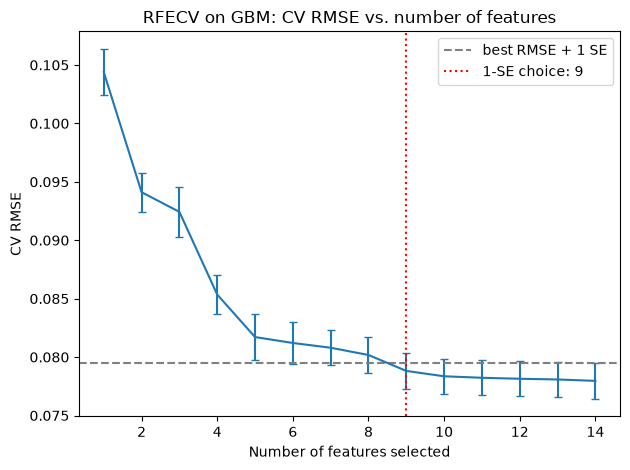

In [29]:
sel = GBModel.named_steps["featureSelec"]
n_folds = cv.get_n_splits()

cv_results = pd.DataFrame({
    "n_features": sel.cv_results_["n_features"],
    "rmse": -sel.cv_results_["mean_test_score"],
    "se": sel.cv_results_["std_test_score"] / np.sqrt(n_folds),
})

best = cv_results["rmse"].min()
threshold = best + cv_results.loc[cv_results["rmse"].idxmin(), "se"]
n_one_se = cv_results.loc[cv_results["rmse"] <= threshold, "n_features"].min()

plt.figure()
plt.errorbar(cv_results["n_features"], cv_results["rmse"], yerr=cv_results["se"], capsize=3)
plt.axhline(threshold, ls="--", color="gray", label="best RMSE + 1 SE")
plt.axvline(n_one_se, ls=":", color="red", label=f"1-SE choice: {n_one_se}")
plt.xlabel("Number of features selected")
plt.ylabel("CV RMSE")
plt.title("RFECV on GBM: CV RMSE vs. number of features")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
GBModel2 = Pipeline([("prep", preprocess), ("featureSelec", RFE(estimator= GradientBoostingRegressor(random_state=42), n_features_to_select=1)),
                    ("model", GradientBoostingRegressor(random_state=42))])
GBModel2.fit(X_train, y_train, model__sample_weight=w_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('featureSelec', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['spendRate','expPerStudent','ugTotal',...,'testScoreMissing', 'admRateMissing','division']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ind', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

Ranking

In [53]:
names = GBModel2["prep"].get_feature_names_out()
order = pd.Series(GBModel2["featureSelec"].ranking_, index=names).sort_values(ascending=False)
print(order)
print(X_train.columns)

cat__division_D-I FCS            14
cat__division_D-I no football    13
cat__division_D-III              12
ind__testScoreMissing            11
cat__division_D-II               10
ind__admRateMissing               9
num__adminShare                   8
num__spendRate                    7
num__instrShare                   6
num__expPerStudent                5
num__admRate                      4
num__upPell                       3
num__ugTotal                      2
num__testScore                    1
dtype: int64
Index(['spendRate', 'expPerStudent', 'ugTotal', 'admRate', 'testScore',
       'upPell', 'instrShare', 'adminShare', 'testScoreMissing',
       'admRateMissing', 'division'],
      dtype='str')


Ablation

In [68]:
results2 = {}

res = cross_validate(pipes["gbm"], X_train, y_train, cv=cv,
                         scoring=["neg_root_mean_squared_error"],
                         params={"model__sample_weight": w_train})
results2["Base"] = {
        "rmse": -res["test_neg_root_mean_squared_error"]
}

for cols in X_train.columns:
    X_model = X_train.drop(columns=cols)

    num2 = [c for c in num if c != cols]
    ind2 = [c for c in ind if c != cols]
    cat2 = [c for c in cat if c != cols]

    preprocess2 = ColumnTransformer([
        ("num2", Pipeline([("impute", SimpleImputer(strategy="median")),
                           ("scale",  StandardScaler())]), num2),
        ("ind2", "passthrough", ind2),
        ("cat2", OneHotEncoder(drop="first", handle_unknown="ignore"), cat2),
    ])

    GBModel3 = Pipeline([("prep", preprocess2), ("model", GradientBoostingRegressor(random_state=42))])

    res = cross_validate(GBModel3, X_model, y_train, cv=cv,
                        scoring=["neg_root_mean_squared_error"],
                        params={"model__sample_weight": w_train})
    results2[cols] = {
        "rmse": -res["test_neg_root_mean_squared_error"]
    }
    

In [ ]:
rmseScores = {col: results2[col]["rmse"] for col in results2.keys()}
rmseScores = pd.DataFrame(rmseScores).transpose()


                   0    1    2    3    4    5   ...   19   20   21   22   23   24
Base              0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0  0.0
admRate           NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
admRateMissing    NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
adminShare        NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
division          NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
expPerStudent     NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
instrShare        NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
spendRate         NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
testScore         NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
testScoreMissing  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
ugTotal           NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN
upPell          